Link video:
https://youtu.be/MjoztgYS_gY

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

import xgboost as xgb

import optuna
from optuna.samplers import TPESampler

import warnings
warnings.filterwarnings('ignore')

# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")

Libraries imported successfully!


c:\Users\Angelyn\anaconda3\envs\Model_Deployment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
!nvidia-smi

Thu Jul  2 17:40:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.66                 Driver Version: 591.66         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   39C    P8              3W /   35W |       0MiB /   6141MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Load Data

In [3]:
train_df = pd.read_csv('data/data_B.csv')

print(f"Training data shape: {train_df.shape}")
train_df.head()


Training data shape: (25000, 29)


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x15309,CUS_0xaa66,April,NaN,32,841-06-2917,Architect,14995.29,NaN,...,Bad,4593.28,29.968714,3 Years and 2 Months,Yes,60.535964,54.73854091370111,Low_spent_Medium_value_payments,278.586245369556,Poor
1,1,0x8bb6,CUS_0x7d83,January,Dasguptaj,30,227-93-6471,Lawyer,74902.8,6272.900000,...,Bad,2900.49,28.086006,12 Years and 9 Months,Yes,534.751534,52.25901203477476,High_spent_Large_value_payments,280.27945391259857,Poor
2,2,0xe016,CUS_0x71aa,January,Nicholasq,22,632-01-7252,Lawyer,20574.71,1813.559167,...,Bad,2592.78,32.525087,12 Years and 1 Months,Yes,88.759975,77.89308197841973,Low_spent_Large_value_payments,284.70286002007293,Poor
3,3,0xbffb,CUS_0x59b6,February,Scuffhamk,53,315-03-3600,Writer,111090.06,9192.505000,...,Good,575.32,25.360743,27 Years and 6 Months,No,149.079658,436.7372848909153,Low_spent_Medium_value_payments,613.4335567793378,Standard
4,4,0xa96e,CUS_0x36a1,January,Miyoung Kimh,42,286-88-7128,Teacher,19214.965,1730.247083,...,Good,498.81,37.600265,28 Years and 9 Months,No,0.000000,217.7804724472987,!@9#%8,245.2442358860347,Good


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22534 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21244 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [5]:
print(f'Targets:')
print(train_df['Credit_Score'].value_counts()) 

Targets:
Credit_Score
Standard    13257
Poor         7197
Good         4546
Name: count, dtype: int64


## Data Cleaning

### Inconsistent Data Types

In [6]:
for col in train_df.columns:
    print(f"\nValue counts for {col}:")
    print(train_df[col].value_counts())


Value counts for Unnamed: 0:
Unnamed: 0
0        1
16650    1
16672    1
16671    1
16670    1
        ..
8331     1
8330     1
8329     1
8328     1
24999    1
Name: count, Length: 25000, dtype: int64

Value counts for ID:
ID
0x15309    1
0x1a361    1
0x1cbd7    1
0x13d19    1
0x1637a    1
          ..
0x53e9     1
0x9036     1
0x10d4a    1
0x1aca7    1
0x12b25    1
Name: count, Length: 25000, dtype: int64

Value counts for Customer_ID:
Customer_ID
CUS_0x302f    7
CUS_0xa663    7
CUS_0xafeb    7
CUS_0x8c13    7
CUS_0xb319    7
             ..
CUS_0x5513    1
CUS_0x60b6    1
CUS_0x5c4f    1
CUS_0x81e6    1
CUS_0x6649    1
Name: count, Length: 11275, dtype: int64

Value counts for Month:
Month
March       3184
July        3175
January     3137
August      3136
April       3122
February    3106
May         3082
June        3058
Name: count, dtype: int64

Value counts for Name:
Name
Nicko              17
Phila              15
Davidc             15
Jessicad           14
Paulr             

Column Age, Num_of_Loan, dan Num_of_Delayed_Payment harus dikonversi menjadi tipe integer karena saat ini masih bertipe object atau string.

In [7]:
int_cols = ["Age", "Num_of_Loan", "Num_of_Delayed_Payment"]

for col in int_cols:
    train_df[col] = (train_df[col].astype(str).str.replace("_", "", regex=False))
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce")
    train_df[col] = train_df[col].astype("Int64")

Column Annual_Income, Changed_Credit_Limit, Outstanding_Debt, Amount_invested_monthly, dan Monthly_Balance harus dikonversi menjadi tipe float, bukan object atau string.

In [8]:
float_cols = ["Annual_Income", "Changed_Credit_Limit", "Outstanding_Debt", "Amount_invested_monthly", "Monthly_Balance"]

for col in float_cols:
    train_df[col] = (train_df[col].astype(str).str.replace("_", "", regex=False).str.strip())
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce")

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22534 non-null  object 
 5   Age                       25000 non-null  Int64  
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  float64
 9   Monthly_Inhand_Salary     21244 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  Int64  
 14  Type_o

### Missing Values

In [10]:
print("\nMissing Values:")
print(train_df.isnull().sum())


Missing Values:
Unnamed: 0                     0
ID                             0
Customer_ID                    0
Month                          0
Name                        2466
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       3756
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                2848
Delay_from_due_date            0
Num_of_Delayed_Payment      1733
Changed_Credit_Limit         532
Num_Credit_Inquiries         490
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          2292
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     1060
Payment_Behaviour              0
Monthly_Balance              301
Credit_Score                   0
dtype: int64


Ada 9 column yang memiliki missing values. Namun, hanya 8 column saja yang akan diimputasi, karena column 'Name' akan saya drop nantinya.

In [11]:
missing_cols = [
    'Monthly_Inhand_Salary',
    'Type_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Credit_History_Age',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in missing_cols:
    print(f"\nKolom: {col}")
    print(f"Dtype: {train_df[col].dtype}")
    print("Value Counts:")
    print(train_df[col].value_counts(dropna=False))


Kolom: Monthly_Inhand_Salary
Dtype: float64
Value Counts:
Monthly_Inhand_Salary
NaN            3756
1111.860833       7
1362.110000       6
1905.030417       6
7959.130000       6
               ... 
1372.902589       1
4699.363333       1
7266.487500       1
1611.188333       1
2767.231667       1
Name: count, Length: 10920, dtype: int64

Kolom: Type_of_Loan
Dtype: object
Value Counts:
Type_of_Loan
NaN                                                                                2848
Not Specified                                                                       367
Student Loan                                                                        317
Credit-Builder Loan                                                                 315
Personal Loan                                                                       304
                                                                                   ... 
Personal Loan, Payday Loan, Auto Loan, and Personal Loan            

In [12]:
numeric_missing_cols = [
    'Monthly_Inhand_Salary',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in numeric_missing_cols:
    train_df[col] = train_df[col].fillna(
        train_df[col].median()
    )

categorical_missing_cols = [
    'Type_of_Loan',
    'Credit_History_Age'
]

for col in categorical_missing_cols:
    train_df[col] = train_df[col].fillna(
        train_df[col].mode()[0]
    )

In [13]:
print(f'Missing values after imputation:')
print(train_df.isnull().sum())

Missing values after imputation:
Unnamed: 0                     0
ID                             0
Customer_ID                    0
Month                          0
Name                        2466
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                   0
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit           0
Num_Credit_Inquiries           0
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly        0
Payment_Behaviour              0
Monthly_Balance                0
Credit_Score                   0
dtype: int

### Handling Invalid String and Values

Saya memeriksa apakah terdapat invalid string di setiap column, misalnya berupa simbol _ atau ______

In [14]:
for col in train_df:
    print(f"\nKolom: {col}")
    print(f"Dtype: {train_df[col].dtype}")
    print("Value Counts:")
    print(train_df[col].value_counts(dropna=False))


Kolom: Unnamed: 0
Dtype: int64
Value Counts:
Unnamed: 0
0        1
16650    1
16672    1
16671    1
16670    1
        ..
8331     1
8330     1
8329     1
8328     1
24999    1
Name: count, Length: 25000, dtype: int64

Kolom: ID
Dtype: object
Value Counts:
ID
0x15309    1
0x1a361    1
0x1cbd7    1
0x13d19    1
0x1637a    1
          ..
0x53e9     1
0x9036     1
0x10d4a    1
0x1aca7    1
0x12b25    1
Name: count, Length: 25000, dtype: int64

Kolom: Customer_ID
Dtype: object
Value Counts:
Customer_ID
CUS_0x302f    7
CUS_0xa663    7
CUS_0xafeb    7
CUS_0x8c13    7
CUS_0xb319    7
             ..
CUS_0x5513    1
CUS_0x60b6    1
CUS_0x5c4f    1
CUS_0x81e6    1
CUS_0x6649    1
Name: count, Length: 11275, dtype: int64

Kolom: Month
Dtype: object
Value Counts:
Month
March       3184
July        3175
January     3137
August      3136
April       3122
February    3106
May         3082
June        3058
Name: count, dtype: int64

Kolom: Name
Dtype: object
Value Counts:
Name
NaN             2466
N

Ternyata ada 3 column yang memiliki invlaid string yaitu Occupation, Credit_Mix, dan Payment_Behaviour. Di sini saya ubah menjadi nilai kosong (np.nan) kemudian saya imputasi menggunakan modus.

In [15]:
invalid_string = {
    'Payment_Behaviour': '!@9#%8',
    'Credit_Mix': '_',
    'Occupation': '_______'
}

for col, invalid in invalid_string.items():
    train_df[col] = train_df[col].replace(invalid, np.nan)

for col in invalid_string.keys():
    train_df[col] = train_df[col].fillna(
        train_df[col].mode().iloc[0]
    )

In [16]:
train_df[['Payment_Behaviour', 'Credit_Mix', 'Occupation']].isnull().sum()

Payment_Behaviour    0
Credit_Mix           0
Occupation           0
dtype: int64

In [17]:
# statistical summary
train_df.describe()

,Unnamed: 0,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,25000.000000,25000.0,2.500000e+04,25000.000000,25000.000000,25000.000000,25000.000000,25000.0,25000.000000,25000.0,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,2.500000e+04
mean,12499.500000,117.09044,1.848748e+05,4039.981681,16.189320,22.204800,72.883720,2.87612,21.029360,31.77604,10.343160,27.056160,1418.369978,32.294362,1300.578910,636.576621,-2.666667e+22
std,7217.022701,716.795846,1.481741e+06,2945.527930,113.979946,128.635884,464.533619,61.879436,14.815959,234.016453,6.703808,189.974944,1145.176915,5.136061,7938.267492,2045.095259,2.981364e+24
min,0.000000,-500.0,7.006035e+03,303.645417,-1.000000,0.000000,1.000000,-100.0,-5.000000,-3.0,-6.490000,0.000000,0.230000,20.257073,0.000000,0.000000,-3.333333e+26
25%,6249.750000,24.0,1.954887e+04,1804.031667,3.000000,4.000000,8.000000,1.0,10.000000,9.0,5.420000,3.000000,563.310000,28.007510,30.622965,78.286292,2.700951e+02
50%,12499.500000,33.0,3.782496e+04,3118.399167,6.000000,5.000000,13.000000,3.0,18.000000,14.0,9.370000,6.000000,1170.255000,32.276799,69.528976,138.572608,3.366188e+02
75%,18749.250000,42.0,7.302054e+04,5390.500625,7.000000,7.000000,20.000000,5.0,28.000000,18.0,14.612500,9.000000,1925.940000,36.553116,161.078485,258.267687,4.693419e+02
max,24999.000000,8666.0,2.417715e+07,15204.633333,1798.000000,1495.000000,5774.000000,1496.0,67.000000,4397.0,36.490000,2587.000000,4998.070000,49.254983,82256.000000,10000.000000,1.576289e+03


Berdasarkan ringkasan statistik di atas, banyak kolom yang memiliki nilai tidak valid. Sebagai contoh, pada kolom Age terdapat nilai 8.666, yang jelas tidak mungkin merepresentasikan usia manusia, jumlah rekening yang negatif, nasabah dengan 1.798 rekening bank, jumlah kartu kredit sebanyak 1.495, suku bunga mencapai 5.774%, jumlah pinjaman -100 dan 1.496, dan lainnya. Oleh karena itu, dilakukan pembatasan agar nilai-nilai tersebut tetap masuk akal. 

In [18]:
# Age
train_df.loc[
    (train_df['Age'] < 18) |
    (train_df['Age'] > 100),
    'Age'
] = np.nan

# Num_Bank_Accounts
train_df.loc[
    (train_df['Num_Bank_Accounts'] < 0) |
    (train_df['Num_Bank_Accounts'] > 20),
    'Num_Bank_Accounts'
] = np.nan

# Num_Credit_Card
train_df.loc[
    train_df['Num_Credit_Card'] > 20,
    'Num_Credit_Card'
] = np.nan

# Interest_Rate
train_df.loc[
    train_df['Interest_Rate'] > 100,
    'Interest_Rate'
] = np.nan

# Num_of_Loan
train_df.loc[
    (train_df['Num_of_Loan'] < 0) |
    (train_df['Num_of_Loan'] > 50),
    'Num_of_Loan'
] = np.nan

# Delay_from_due_date
train_df.loc[
    train_df['Delay_from_due_date'] < 0,
    'Delay_from_due_date'
] = np.nan

# Delay_of_Delayed_Payment
train_df.loc[
    (train_df['Num_of_Delayed_Payment'] < 0) |
    (train_df['Num_of_Delayed_Payment'] > 100),
    'Num_of_Delayed_Payment'
] = np.nan

# Num_Credit_Inquiries
train_df.loc[
    train_df['Num_Credit_Inquiries'] > 100,
    'Num_Credit_Inquiries'
] = np.nan

# Monthly_Balance
train_df.loc[
    train_df['Monthly_Balance'].abs() > 1e6,
    'Monthly_Balance'
] = np.nan

Nilai-nilai yang tidak masuk akal tersebut, saya ubah menjadi nilai kosong (np.nan) kemudian saya imputasi menggunakan median.

In [19]:
cols_invalid = [
    'Age',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Num_Credit_Inquiries',
    'Monthly_Balance'
]

train_df[cols_invalid].isnull().sum()

Age                       2106
Num_Bank_Accounts          298
Num_Credit_Card            554
Interest_Rate              515
Num_of_Loan               1103
Delay_from_due_date        154
Num_of_Delayed_Payment     352
Num_Credit_Inquiries       401
Monthly_Balance              2
dtype: int64

In [20]:
for col in cols_invalid:
    train_df[col] = train_df[col].fillna(train_df[col].median())

print(f'Missing values after handling invalid values:')
print(train_df.isnull().sum())

Missing values after handling invalid values:
Unnamed: 0                     0
ID                             0
Customer_ID                    0
Month                          0
Name                        2466
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                   0
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit           0
Num_Credit_Inquiries           0
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly        0
Payment_Behaviour              0
Monthly_Balance                0
Credit_Score                  

## Exploratory Data Analysis

### Target distribution

In [21]:
print(f'Targets:')
print(train_df['Credit_Score'].value_counts()) 

Targets:
Credit_Score
Standard    13257
Poor         7197
Good         4546
Name: count, dtype: int64


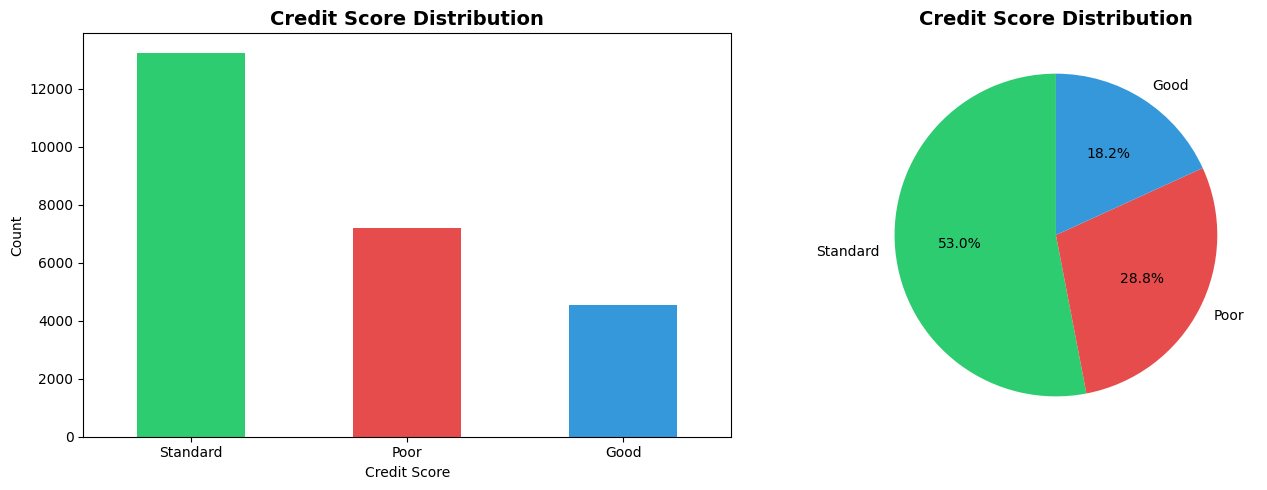

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count Plot
train_df['Credit_Score'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c4c', '#3498db'])
axes[0].set_title('Credit Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie Chart
train_df['Credit_Score'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#2ecc71', '#e74c4c', '#3498db'], startangle=90)
axes[1].set_title('Credit Score Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Berdasarkan distribusi target Credit_Score, kelas Standard merupakan kelas yang paling dominan dengan proporsi sebesar 53% (sekitar 13.257 data). Kemudian, kelas Poor mencakup 28.8% (7.197 data), sedangkan kelas Good hanya sekitar 18.2% (4.546 data). Kondisi ini menunjukkan ketidakseimbangan kelas (class imbalance) pada dataset.

### Categorical features analysis

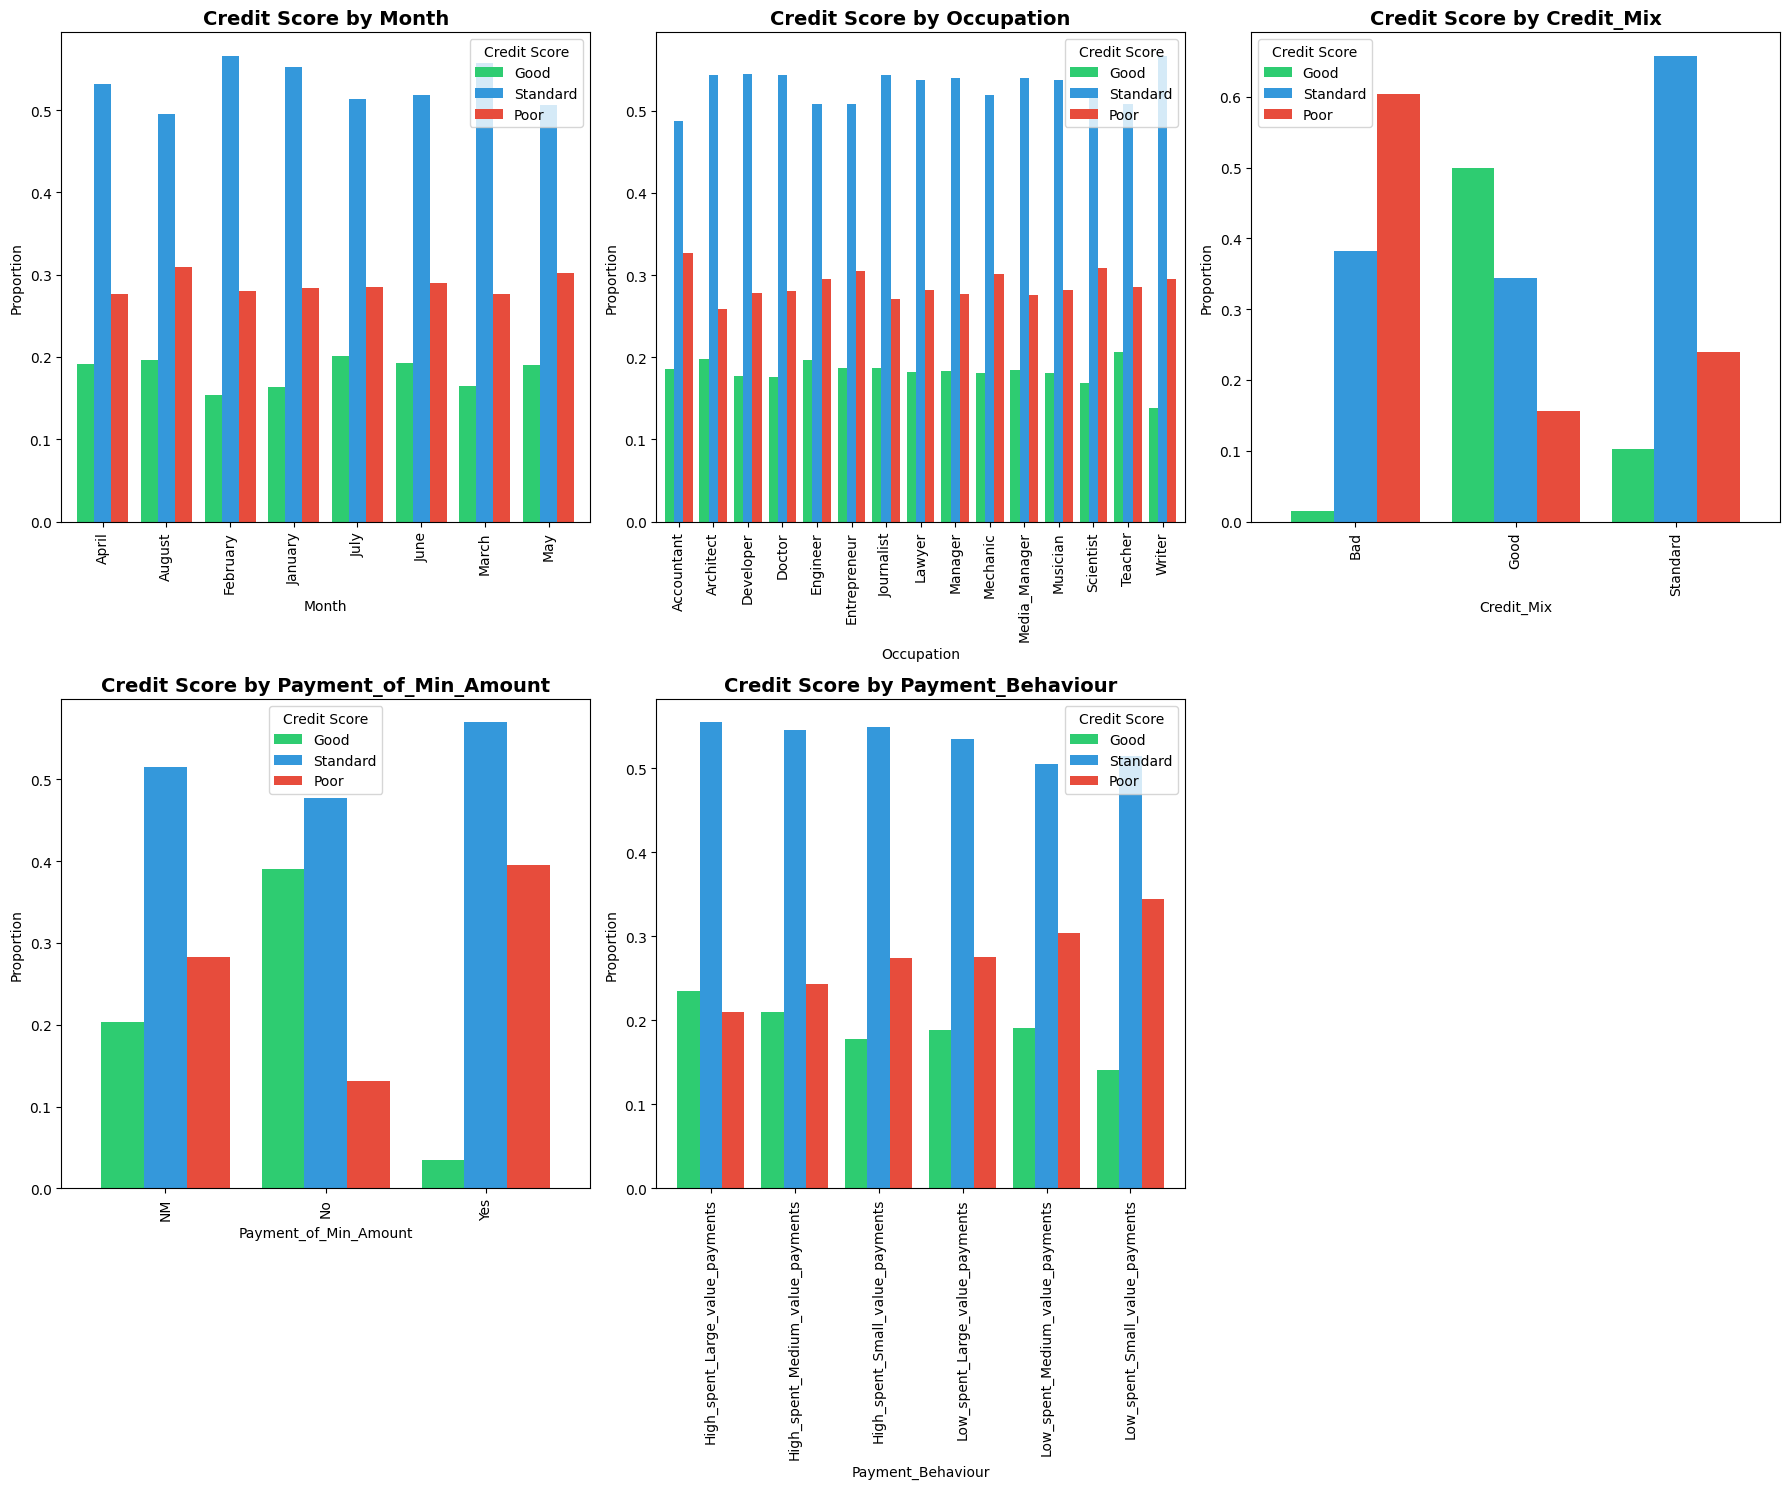

In [23]:
categorical_features = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

fig, axes = plt.subplots(2, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, col in enumerate(categorical_features):
    crosstab = pd.crosstab(train_df[col], train_df['Credit_Score'], normalize='index')
    crosstab = crosstab.reindex(columns=['Good', 'Standard', 'Poor'])
    crosstab.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#3498db', '#e74c3c'], width=0.8)

    axes[idx].set_title(f'Credit Score by {col}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Proportion')
    axes[idx].tick_params(axis='x', rotation=90)
    axes[idx].legend(title='Credit Score')

for i in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Berdasarkan analisis fitur kategorikal, Credit_Mix, Payment_of_Min_Amount, dan Payment_Behaviour menunjukkan hubungan yang paling kuat terhadap Credit_Score. Hal ini terlihat dari adanya perbedaan distribusi yang cukup jelas antara kelas Good, Standard, dan Poor pada masing-masing kategori. Pada variabel Credit_Mix, nasabah dengan kelas Good Credit_Mix cenderung memiliki proporsi Credit_Score Good yang lebih tinggi, sedangkan kelas Bad Credit_Mix didominasi oleh Credit_Score Poor. Variabel Payment_of_Min_Amount dan Payment_Behaviour juga menunjukkan pola yang konsisten, dimana perilaku pembayaran (Payment_Behaviour) yang lebih baik cenderung berkaitan dengan kualitas skor kredit yang lebih tinggi.

Sedangkan, variable Month dan Occupation menunjukkan distribusi Credit Score yang relatif serupa pada hampir seluruh kategori. Jadi, dapat disimpulkan bahwa kedua variabel ini memiliki pengaruh yang lebih kecil dalam membedakan kualitas kredit nasabah.

### Numerical features analysis

In [24]:
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_cols)

['Unnamed: 0', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']


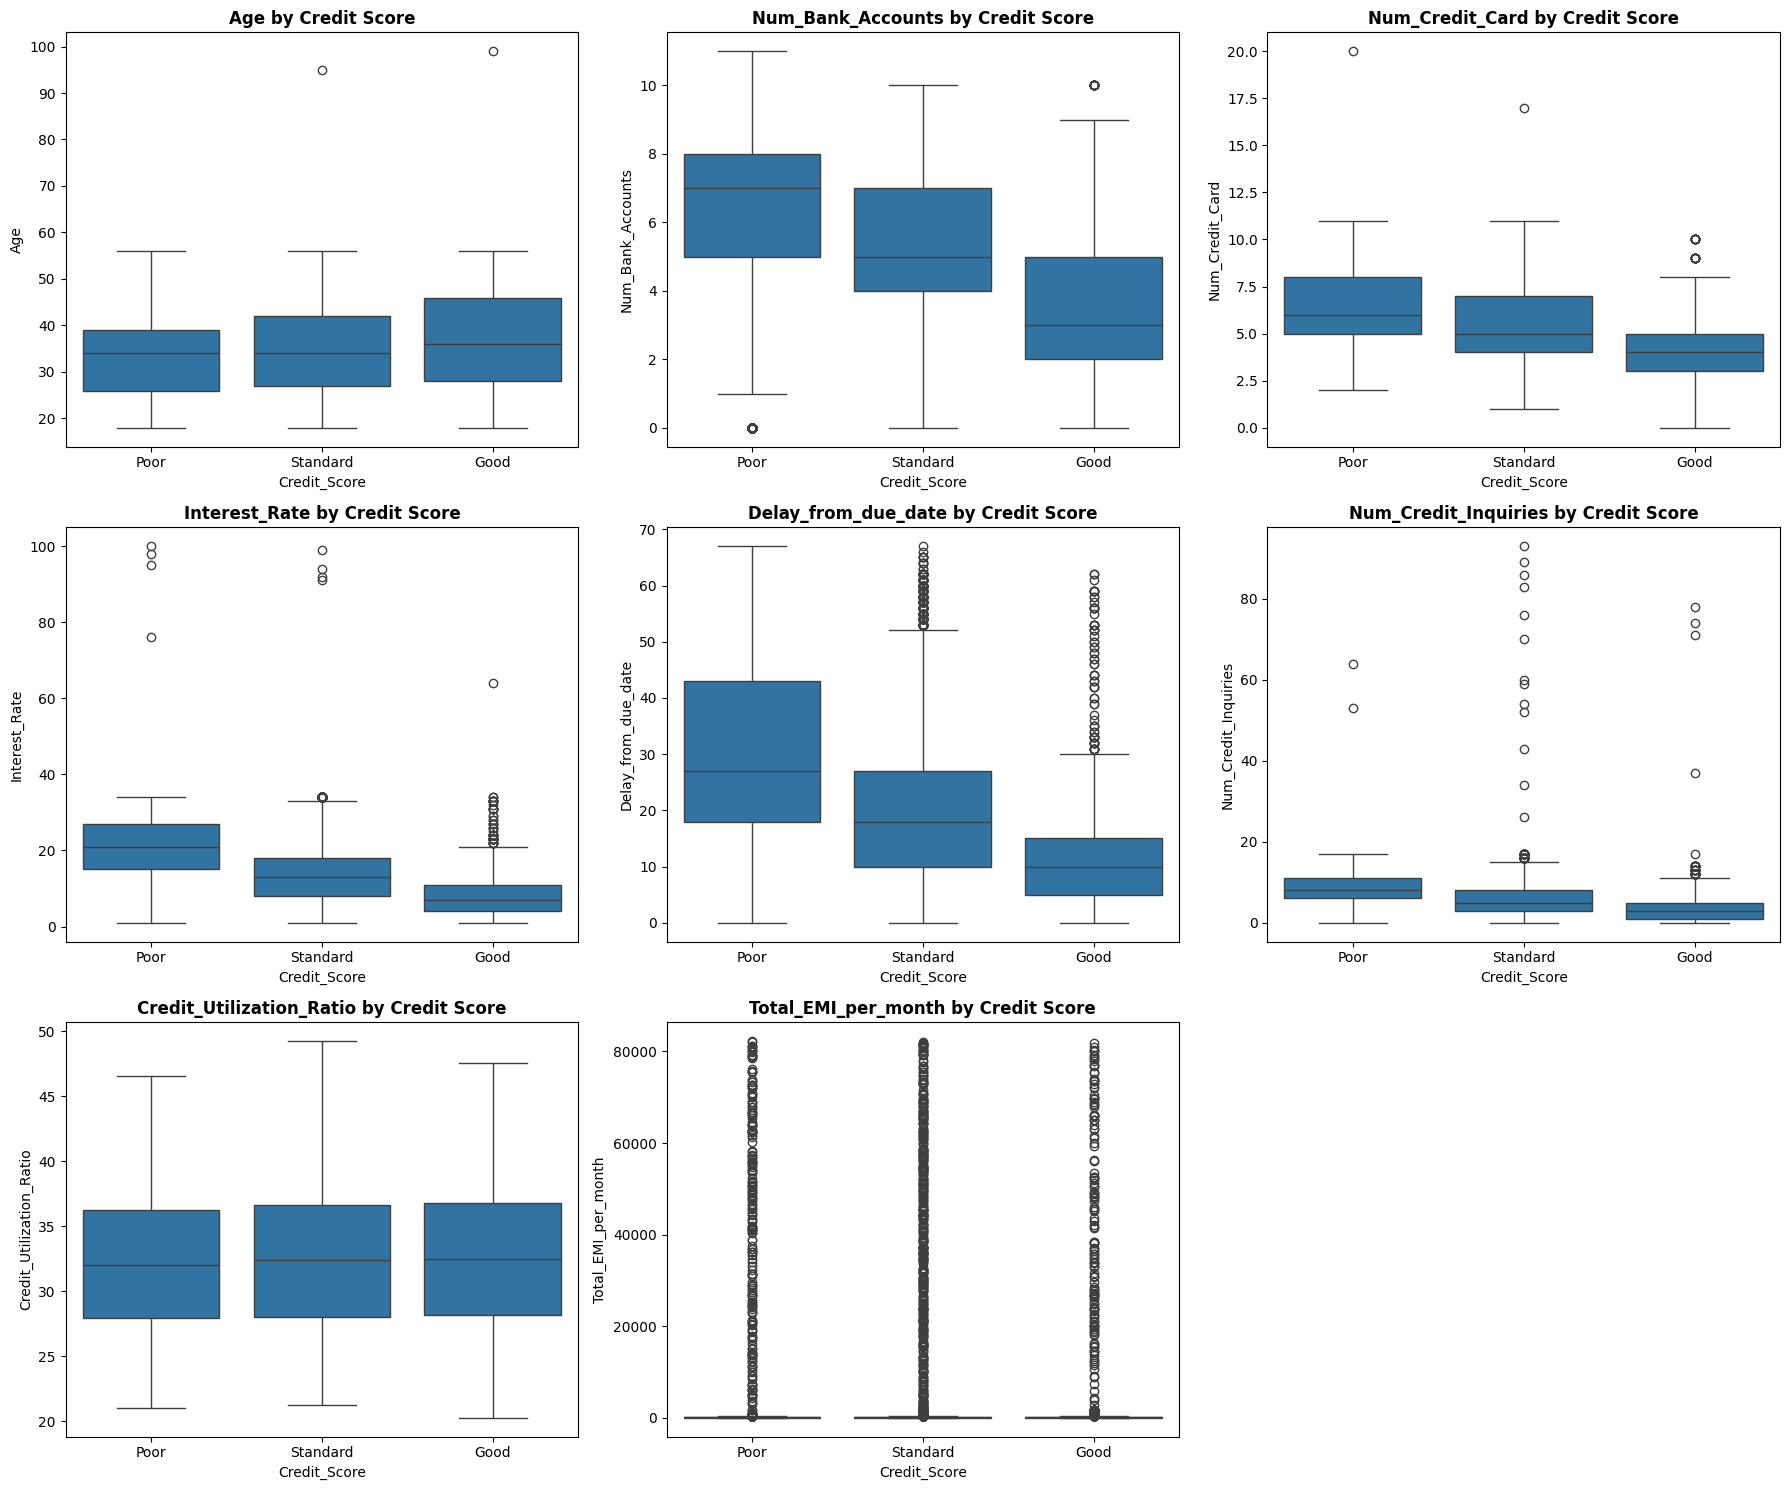

In [25]:
numerical_features = ['Age', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 
                      'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month']

fig, axes = plt.subplots(3, 3, figsize=(18,15))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    sns.boxplot(data=train_df, x='Credit_Score', y=col, ax=axes[idx])
    axes[idx].set_title(f'{col} by Credit Score', fontsize=12, fontweight='bold')

for i in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Berdasarkan analisis fitur numerik, Delay_from_due_date merupakan variabel yang menunjukkan hubungan paling kuat dengan Credit_Score. Nasabah dengan Credit_Score Poor memiliki tingkat keterlambatan pembayaran yang jauh lebih tinggi dibandingkan nasabah dengan Score_Credit Good, sedangkan kategori Standard berada di antara keduanya. Hal ini menunjukkan bahwa riwayat keterlambatan pembayaran merupakan salah satu indikator utama dalam penilaian kualitas kredit nasabah.

Selain itu, Interest_Rate juga menunjukkan pola yang cukup jelas, dimana nasabah dengan Credit_Score Poor cenderung memiliki tingkat suku bunga yang lebih tinggi dibandingkan nasabah dengan Credit_Score Good. Hal ini menandakan bahwa nasabah dengan risiko kredit yang lebih tinggi umumnya dikenakan bunga yang lebih besar oleh bank.

Variabel Num_Credit_Inquiries juga memperlihatkan kecenderungan menurun dari kategori Poor ke Good. Nasabah dengan Credit_Score Poor memiliki jumlah pengajuan kredit yang lebih tinggi dibandingkan nasabah dengan Credit_Score Good, yang artinya bahwa Num_Credit_Inquiries dapat menjadi indikator risiko kredit.

Sementara itu, variabel seperti Age, Credit_Utilization_Ratio, dan Total_EMI_per_month tidak menunjukkan perbedaan distribusi yang signifikan antar kelas Credit_Score. Variabel Num_Bank_Accounts dan Num_Credit_Card menunjukkan perbedaan distribusi, namun pola pemisahan antar kelas tidak sekuat fitur yang berkaitan langsung dengan perilaku pembayaran dan riwayat kredit.

## Feature Engineering

### Type conversion

Saya melakukan feature engineering pada fitur Credit_History_Age. Karena kolom ini berbentuk teks, yaitu 22 Years and 1 Months, maka saya mengubahnya menjadi jumlah bulan, yaitu 265 bulan. Transformasi ini dilakukan agar informasi riwayat kredit dapat direpresentasikan dalam bentuk numerik yang lebih sesuai untuk proses pelatihan model nantinya. Setelah konversi berhasil dilakukan, kolom asli saya hapus dan diganti dengan kolom Credit_History_Months.

In [26]:
train_df['Credit_History_Months'] = (
    train_df['Credit_History_Age']
    .str.extract(r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?')
    .astype(float)
    .pipe(lambda x: x[0] * 12 + x[1])
)

In [27]:
train_df[['Credit_History_Age', 'Credit_History_Months']].head()

,Credit_History_Age,Credit_History_Months
0,3 Years and 2 Months,38.0
1,12 Years and 9 Months,153.0
2,12 Years and 1 Months,145.0
3,27 Years and 6 Months,330.0
4,28 Years and 9 Months,345.0


In [28]:
train_df.drop(columns=['Credit_History_Age'], inplace=True)
train_df

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Months
0,0,0x15309,CUS_0xaa66,April,NaN,32,841-06-2917,Architect,14995.290,3118.399167,...,Bad,4593.28,29.968714,Yes,60.535964,54.738541,Low_spent_Medium_value_payments,278.586245,Poor,38.0
1,1,0x8bb6,CUS_0x7d83,January,Dasguptaj,30,227-93-6471,Lawyer,74902.800,6272.900000,...,Bad,2900.49,28.086006,Yes,534.751534,52.259012,High_spent_Large_value_payments,280.279454,Poor,153.0
2,2,0xe016,CUS_0x71aa,January,Nicholasq,22,632-01-7252,Lawyer,20574.710,1813.559167,...,Bad,2592.78,32.525087,Yes,88.759975,77.893082,Low_spent_Large_value_payments,284.702860,Poor,145.0
3,3,0xbffb,CUS_0x59b6,February,Scuffhamk,53,315-03-3600,Writer,111090.060,9192.505000,...,Good,575.32,25.360743,No,149.079658,436.737285,Low_spent_Medium_value_payments,613.433557,Standard,330.0
4,4,0xa96e,CUS_0x36a1,January,Miyoung Kimh,42,286-88-7128,Teacher,19214.965,1730.247083,...,Good,498.81,37.600265,No,0.000000,217.780472,Low_spent_Small_value_payments,245.244236,Good,345.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24995,0x1e384,CUS_0xc2cb,July,Kimr,38,523-96-3939,Doctor,22387.125,3118.399167,...,Standard,1389.37,26.578408,No,0.000000,64.559076,High_spent_Medium_value_payments,353.200299,Good,323.0
24996,24996,0x23c9c,CUS_0x412f,March,Joyceg,22,319-02-6843,Manager,29437.240,2645.103333,...,Bad,3377.59,26.974691,Yes,116.004348,109.083520,Low_spent_Small_value_payments,329.422465,Poor,51.0
24997,24997,0x21643,CUS_0x1efd,February,NaN,34,966-55-9007,Teacher,17933.840,1393.486667,...,Standard,1660.50,32.000303,NM,48.006051,101.662783,Low_spent_Small_value_payments,279.679833,Standard,154.0
24998,24998,0x157df,CUS_0x5db2,June,Paulr,22,929-83-1124,Musician,9400.430,847.369167,...,Bad,4505.63,39.686679,Yes,30.338701,50.662519,Low_spent_Medium_value_payments,283.735696,Standard,86.0


### Drop Unnecessary Columns

In [29]:
drop_cols = [
    'Unnamed: 0',
    'ID',
    'Customer_ID',
    'Name',
    'SSN'
]

train_df.drop(columns=drop_cols, inplace=True)

Column ini di drop karena tidak cukup relevan untuk memprediksi Credit_Score nasabah.

In [30]:
train_df.columns.tolist()

['Month',
 'Age',
 'Occupation',
 'Annual_Income',
 'Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Type_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Credit_Mix',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Payment_of_Min_Amount',
 'Total_EMI_per_month',
 'Amount_invested_monthly',
 'Payment_Behaviour',
 'Monthly_Balance',
 'Credit_Score',
 'Credit_History_Months']

### Feature Engineering

In [31]:
def feature_engineering(df):
    df = df.copy()

    # Debt vs Income
    df['Debt_vs_Income'] = (df['Outstanding_Debt'] / (df['Annual_Income'] + 1))

    # EMI burden
    df['EMI_burden'] = (df['Total_EMI_per_month'] / (df['Monthly_Inhand_Salary'] + 1))

    # Investment habit
    df['Investment_Habit'] = (df['Amount_invested_monthly'] / (df['Monthly_Inhand_Salary'] + 1))

    # Credit history quality
    df['Credit_History_Quality'] = (df['Credit_History_Months'] / (df['Age'] * 12 + 1))

    # Delayed payment ratio
    df['Delayed_Payment_Ratio'] = (df['Num_of_Delayed_Payment'] / (df['Num_of_Loan'] + 1))

    # Inquiry per Loan
    df['Inquiry_per_Loan'] = (df['Num_Credit_Inquiries'] / (df['Num_of_Loan'] + 1))

    # Loan per Bank Account
    df['Loan_per_Account'] = (df['Num_of_Loan'] / (df['Num_Bank_Accounts'] + 1))

    # Total Credit Exposure
    df['Total_Credit_Exposure'] = (df['Outstanding_Debt'] + df['Total_EMI_per_month'])

    # Financial Stability Score
    df['Financial_Stability_Score'] = (df['Monthly_Balance'] + df['Amount_invested_monthly'] - df['Outstanding_Debt'])

    # High risk customer
    df['High_Risk_Customer'] = (df['Delay_from_due_date'] > 30).astype('Int64')

    return df

# Apply feature engineering
train_df = feature_engineering(train_df)

print(f'After feature engineering: {train_df.shape}')
print(f'\nNew features added:')
print(train_df.columns.tolist())


After feature engineering: (25000, 34)

New features added:
['Month', 'Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score', 'Credit_History_Months', 'Debt_vs_Income', 'EMI_burden', 'Investment_Habit', 'Credit_History_Quality', 'Delayed_Payment_Ratio', 'Inquiry_per_Loan', 'Loan_per_Account', 'Total_Credit_Exposure', 'Financial_Stability_Score', 'High_Risk_Customer']


Penjelasan fitur-fitur baru:

Debt_vs_Income => mengukur proporsi hutang nasabah terhadap pendapatannya. Semakin besar hutang dibandingkan pendapatan, maka nasabah semakin berisiko.

EMI_burden => mengukur total cicilan terhadap gaji nasabah perbulan.

Invesment_Habit => mengukur kebiasaan investasi nasabah.

Credit_History_Quality => mengukur seberapa lama pengalam kredit dibandingkan umur nasabah.

Credit_Card_Intensity => mengukur jumlah credit card dibandingkan dengan usia nasabah.

Delayed_Payment_Ratio => mengukur frekuensi keterlambatan nasabah membayar hutang dengan membandingkan jumlah keterlambatan pembayaran dengan jumlah hutangnya.

Inquiry_per_Loan => mengukur intensitas pengajuan kredit nasabah dengan membandingkan jumlah pengajuan kredit dengan jumlah hutang nasabah.

Loan_per_Account => mengukur kepadatan pinjaman dengan  membandingkan jumlah hutang dengan jumlah rekening bank nasabah.

Total_Credit_Exposure => mengukur total eksposur kredit nasabah dengan membandingkan jumlah hutang yang belum dibayar dengan total cicilan nasabah per bulan.

Financial_Stability_Score => mengukur kestabilan kondisi keuangan nasabah dengan membandingkan total uang yang tersisa setelah pendapatan perbulan dikurangi pengeluaran perbulan dengan jumlah uang untuk investasi nasabah per bulan.

High_Risk_Customer => menandai nasabah dengan risiko kredit tinggi dengan mengecek apakah nasabah memiliki keterlambatan pembayaran lebih dari 30 hari.




## Data Preprocessing

In [32]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Month                      25000 non-null  object 
 1   Age                        25000 non-null  Int64  
 2   Occupation                 25000 non-null  object 
 3   Annual_Income              25000 non-null  float64
 4   Monthly_Inhand_Salary      25000 non-null  float64
 5   Num_Bank_Accounts          25000 non-null  float64
 6   Num_Credit_Card            25000 non-null  float64
 7   Interest_Rate              25000 non-null  float64
 8   Num_of_Loan                25000 non-null  Int64  
 9   Type_of_Loan               25000 non-null  object 
 10  Delay_from_due_date        25000 non-null  float64
 11  Num_of_Delayed_Payment     25000 non-null  Int64  
 12  Changed_Credit_Limit       25000 non-null  float64
 13  Num_Credit_Inquiries       25000 non-null  flo

In [33]:
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()
numerical_features = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f'Categorical features after feature engineering: {categorical_features}')   
print(f'Numerical features after feature engineering: {numerical_features}')

Categorical features after feature engineering: ['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']
Numerical features after feature engineering: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Months', 'Debt_vs_Income', 'EMI_burden', 'Investment_Habit', 'Credit_History_Quality', 'Delayed_Payment_Ratio', 'Inquiry_per_Loan', 'Loan_per_Account', 'Total_Credit_Exposure', 'Financial_Stability_Score', 'High_Risk_Customer']


In [34]:
def preprocess_data(df, is_train=True):
    df = df.copy()

    categorical_features = ['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

    numerical_features = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
                            'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 
                            'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Months',
                            'Debt_vs_Income', 'EMI_burden', 'Investment_Habit', 'Credit_History_Quality', 'Delayed_Payment_Ratio', 'Inquiry_per_Loan', 
                            'Loan_per_Account', 'Total_Credit_Exposure', 'Financial_Stability_Score', 'High_Risk_Customer']
    
    # Encode categorical features
    label_encoders = {}
    for col in categorical_features:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col]).astype(int)
        label_encoders[col] = le

    # Select features 
    feature_columns = categorical_features + numerical_features
    X = df[feature_columns]

    if is_train:

        target_encoder = LabelEncoder()
        y = target_encoder.fit_transform(df['Credit_Score'])
        return (X, y, feature_columns, label_encoders, target_encoder)
    else:
        return (X, feature_columns, label_encoders)

# Preprocess training data
X, y, feature_columns, label_encoders, target_encode = preprocess_data(train_df, is_train=True)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print("\nTotal Features :", len(feature_columns))
print(feature_columns)

Features shape: (25000, 33)
Target shape: (25000,)

Total Features : 33
['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Months', 'Debt_vs_Income', 'EMI_burden', 'Investment_Habit', 'Credit_History_Quality', 'Delayed_Payment_Ratio', 'Inquiry_per_Loan', 'Loan_per_Account', 'Total_Credit_Exposure', 'Financial_Stability_Score', 'High_Risk_Customer']


In [35]:
pd.set_option('display.max_columns', None)
train_df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Months,Debt_vs_Income,EMI_burden,Investment_Habit,Credit_History_Quality,Delayed_Payment_Ratio,Inquiry_per_Loan,Loan_per_Account,Total_Credit_Exposure,Financial_Stability_Score,High_Risk_Customer
count,25000.0,2.500000e+04,25000.000000,25000.000000,25000.00000,25000.000000,25000.0,25000.000000,25000.0,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.0,25000.0,25000.0,25000.0,25000.000000,25000.000000,25000.0
mean,34.42576,1.848748e+05,4039.981681,5.367880,5.51956,14.507480,3.50828,21.153920,13.4784,10.343160,5.821360,1418.369978,32.294362,1300.578910,636.576621,401.114720,222.504840,0.059493,0.561301,0.245919,0.575896,3.987305,1.543312,0.62673,2718.948889,-380.678637,0.18964
std,9.690499,1.481741e+06,2945.527930,2.579335,2.05162,8.708429,2.420728,14.704228,5.980863,6.703808,4.149744,1145.176915,5.136061,7938.267492,2045.095259,211.625571,95.604311,0.086811,4.952312,1.169150,0.304794,3.373881,1.532329,0.55072,8021.608306,2401.635327,0.392024
min,18.0,7.006035e+03,303.645417,0.000000,0.00000,1.000000,0.0,0.000000,0.0,-6.490000,0.000000,0.230000,20.257073,0.000000,0.000000,0.007760,1.000000,0.000001,0.000000,0.000000,0.002445,0.0,0.0,0.0,0.770000,-4678.878757,0.0
25%,27.0,1.954887e+04,1804.031667,3.000000,4.00000,8.000000,2.0,10.000000,9.0,5.420000,3.000000,563.310000,28.007510,30.622965,78.286292,270.105358,153.000000,0.009221,0.012167,0.025942,0.36886,2.0,0.75,0.285714,686.348279,-1399.054601,0.0
50%,34.0,3.782496e+04,3118.399167,5.000000,5.00000,13.000000,3.0,18.000000,14.0,9.370000,6.000000,1170.255000,32.276799,69.528976,138.572608,336.618808,231.000000,0.027632,0.024855,0.046681,0.530649,3.0,1.25,0.545455,1295.643714,-460.182365,0.0
75%,41.0,7.302054e+04,5390.500625,7.000000,7.00000,20.000000,5.0,28.000000,18.0,14.612500,8.000000,1925.940000,36.553116,161.078485,258.267687,469.341916,293.000000,0.067224,0.043389,0.081805,0.738019,4.666667,2.0,0.8,2187.580542,196.572782,0.0
max,99.0,2.417715e+07,15204.633333,11.000000,20.00000,100.000000,49.0,67.000000,84.0,36.490000,93.000000,4998.070000,49.254983,82256.000000,10000.000000,1576.288935,404.000000,0.683157,221.121312,26.732845,1.857143,28.0,89.0,6.125,86090.000000,11331.416693,1.0


In [36]:
for col in train_df:
    print(f"\nKolom: {col}")
    print(f"Dtype: {train_df[col].dtype}")
    print("Value Counts:")
    print(train_df[col].value_counts(dropna=False))


Kolom: Month
Dtype: object
Value Counts:
Month
March       3184
July        3175
January     3137
August      3136
April       3122
February    3106
May         3082
June        3058
Name: count, dtype: int64

Kolom: Age
Dtype: Int64
Value Counts:
Age
34    2822
28     783
38     742
31     740
22     733
39     716
23     709
32     707
44     706
43     705
20     702
41     698
36     695
25     694
19     693
29     692
45     690
37     688
26     686
30     678
35     676
40     674
24     670
21     668
27     667
33     658
42     647
18     570
46     425
48     362
55     351
52     335
51     331
50     324
49     323
53     322
54     317
47     315
56      84
99       1
95       1
Name: count, dtype: Int64

Kolom: Occupation
Dtype: object
Value Counts:
Occupation
Lawyer           3426
Scientist        1608
Accountant       1592
Engineer         1572
Architect        1570
Mechanic         1562
Writer           1559
Entrepreneur     1554
Media_Manager    1551
Developer     

## Splitting

In [37]:
# Standard : 2, Poor : 1, Good : 0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Training set : {X_train.shape}, {y_train.shape}")
print(f"Testing set: {X_test.shape}, {y_test.shape}")

print("\nCredit Score in training:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nCredit Score in testing:")
print(pd.Series(y_test).value_counts(normalize=True))

Training set : (20000, 33), (20000,)
Testing set: (5000, 33), (5000,)

Credit Score in training:
2    0.53030
1    0.28785
0    0.18185
Name: proportion, dtype: float64

Credit Score in testing:
2    0.5302
1    0.2880
0    0.1818
Name: proportion, dtype: float64


## Baseline Models

In [49]:
# Scaling  untuk logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Store results
baseline_results = {}

# Logistic Regression
print("Training Logistic Regression Baseline...")
lr_baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_baseline.fit(X_train_scaled, y_train)
lr_train_pred = lr_baseline.predict(X_train_scaled)
lr_pred = lr_baseline.predict(X_test_scaled)
lr_prob = lr_baseline.predict_proba(X_test_scaled) # untuk ROC-AUC

lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_acc = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred, average='weighted')
lr_rec = recall_score(y_test, lr_pred, average='weighted')
lr_f1 = f1_score(y_test, lr_pred, average='weighted')
lr_auc = roc_auc_score(y_test, lr_prob, multi_class='ovr', average='weighted')
baseline_results['Logistic Regression'] = [lr_train_acc, lr_acc, lr_prec, lr_rec, lr_f1, lr_auc]

# Random Forest
print("Training Random Forest Baseline...")
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_baseline.fit(X_train, y_train)
rf_train_pred = rf_baseline.predict(X_train)
rf_pred = rf_baseline.predict(X_test)
rf_prob = rf_baseline.predict_proba(X_test)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, average='weighted')
rf_rec = recall_score(y_test, rf_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_pred, average='weighted')
rf_auc = roc_auc_score(y_test, rf_prob,  multi_class='ovr', average='weighted')
baseline_results['Random Forest'] = [rf_train_acc, rf_acc, rf_prec, rf_rec, rf_f1, rf_auc]

# XGBoost
print("Training XGBoost Baseline...")
xgb_baseline = xgb.XGBClassifier(n_estimators=100, random_state=RANDOM_STATE)
xgb_baseline.fit(X_train, y_train)
xgb_train_pred = xgb_baseline.predict(X_train)
xgb_pred = xgb_baseline.predict(X_test)
xgb_prob = xgb_baseline.predict_proba(X_test)

xgb_train_acc = accuracy_score(y_train, xgb_train_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_prec = precision_score(y_test, xgb_pred, average='weighted')
xgb_rec = recall_score(y_test, xgb_pred, average='weighted')
xgb_f1 = f1_score(y_test, xgb_pred, average='weighted')
xgb_auc = roc_auc_score(y_test, xgb_prob,  multi_class='ovr', average='weighted')
baseline_results['XGBoost'] = [xgb_train_acc, xgb_acc, xgb_prec, xgb_rec, xgb_f1, xgb_auc]

# Display results
baseline_df = pd.DataFrame.from_dict(baseline_results, orient='index', columns=[ 'Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
baseline_df = baseline_df.sort_values('F1-Score', ascending=False)
print("\n=== BASELINE RESULTS ===")
print(baseline_df)

Training Logistic Regression Baseline...
Training Random Forest Baseline...
Training XGBoost Baseline...

=== BASELINE RESULTS ===
                     Train Accuracy  Test Accuracy  Precision  Recall  \
Random Forest                1.0000         0.7396   0.741370  0.7396   
XGBoost                      0.9239         0.7250   0.725088  0.7250   
Logistic Regression          0.6447         0.6506   0.650662  0.6506   

                     F1-Score   ROC-AUC  
Random Forest        0.740094  0.865031  
XGBoost              0.724845  0.856537  
Logistic Regression  0.645965  0.783608  


1. Logistic Regression.
Model Logistic Regression memperoleh Train Accuracy sebesar 0,6447 dan Test Accuracy sebesar 0,6506. Selisih kedua nilai tersebut sangat kecil sehingga menunjukkan bahwa model tidak mengalami overfitting dan memiliki kemampuan generalisasi yang cukup konsisten. Namun, seluruh metrik evaluasi seperti Precision, Recall, F1-Score, dan ROC-AUC merupakan yang terendah dibandingkan model lainnya. Hal ini menunjukkan bahwa Logistic Regression cenderung underfitting, karena sebagai model linear, Logistic Regression belum mampu menangkap hubungan yang kompleks dan non-linear antar fitur pada dataset credit score, seperti hubungan antara Delay_from_due_date, Credit_Mix, Payment_Behaviour, dan fitur hasil feature engineering.

2. Random Forest.
Random Forest menghasilkan performa terbaik pada tahap baseline dengan Train Accuracy sebesar 1,0000, Test Accuracy sebesar 0,7396, Precision sebesar 0,7414, Recall sebesar 0,7396, F1-Score sebesar 0,7401, dan ROC-AUC sebesar 0,8650. Nilai metrik tersebut merupakan yang tertinggi di antara ketiga model. Akan tetapi, terdapat selisih yang cukup besar antara Train Accuracy dan Test Accuracy, yaitu sekitar 0,2604, sehingga menunjukkan adanya overfitting. Model mampu menghafal data latih dengan sangat baik, namun kemampuan generalisasinya terhadap data baru masih terbatas. Oleh karena itu, diperlukan proses hyperparameter tuning dengan mengoptimalkan parameter seperti max_depth, min_samples_split, dan min_samples_leaf agar kompleksitas model dapat dikendalikan sehingga diharapkan mampu mengurangi overfitting dan meningkatkan performa pada data uji.

3. XGBoost.
Model XGBoost memperoleh Train Accuracy sebesar 0,9239 dan Test Accuracy sebesar 0,7250. Nilai Precision, Recall, F1-Score, dan ROC-AUC juga berada di bawah Random Forest, namun masih lebih baik dibandingkan Logistic Regression. Dibandingkan Random Forest, selisih antara Train Accuracy dan Test Accuracy lebih kecil sehingga menunjukkan bahwa tingkat overfitting pada XGBoost lebih rendah. Mengingat XGBoost merupakan algoritma gradient boosting yang umumnya memiliki kemampuan generalisasi yang baik, model ini masih memiliki potensi untuk ditingkatkan melalui proses hyperparameter tuning dengan mengoptimalkan parameter seperti learning_rate, max_depth, subsample, dan colsample_bytree.

4. Berdasarkan hasil evaluasi, seluruh model menghasilkan nilai ROC-AUC di atas 0,78, dengan Random Forest dan XGBoost mencapai 0,8650 dan 0,8565. Nilai ROC-AUC di atas 0,80 umumnya menunjukkan kemampuan klasifikasi yang baik, terutama pada kasus multiclass classification. Hal ini menunjukkan bahwa kedua model berbasis tree memiliki kemampuan yang cukup baik dalam membedakan setiap kelas credit score.

Kesimpulan:
Model Random Forest dan XGBoost memberikan hasil yang lebih baik dibandingkan Logistic Regression. Hal ini menunjukkan bahwa model berbasis tree lebih sesuai untuk dataset ini dibandingkan model linear. Oleh karena itu, selanjutnya perlu melakukan hyperparameter tuning dan saya menggunakan Optuna dengan objective function F1-weighted pada ketiga model untuk memperoleh kombinasi hyperparameter terbaik, meningkatkan kemampuan generalisasi model, serta menentukan model terbaik yang akan digunakan pada proses deployment.

## Optuna Hyperparameter Tuning

Karena distribusi kelas di dataset ini tidak seimbang, saya menggunakan StratifiedKFold. Supaya menjaga proprosi antar kelas pada setiap fold sehingga evaluasi model menjadi lebih stabil dan representatif.

In [39]:
# Cross Validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Saya menggunakan F1-score weighted sebagai objective function karena dataset ini bersifat multiclass dan distribusi antar kelas tidak seimbang. F1-score mengukur keseimbangan antara precision dan recall, sehingga lebih representatif dibandingkan accuracy. 

In [40]:
def objective_lr(trial):
    """Optuna objective for Logistic Regression"""

    params = {
        'C': trial.suggest_float('C', 0.0001, 100, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'saga']),
        'max_iter': trial.suggest_int('max_iter', 500, 3000),
        'random_state': RANDOM_STATE
    }
    
    model = LogisticRegression(**params)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)

    return scores.mean()   

print('Optimizing Logistic Regression...')

# Set a seed for reproducibility
sampler = TPESampler(seed=RANDOM_STATE)

study_lr = optuna.create_study(direction='maximize', study_name='LogisticRegression', sampler=sampler)
study_lr.optimize(objective_lr, n_trials=30, show_progress_bar=True)

print(f"\nBest Logistic Regression F1: {study_lr.best_value}")
print(f"Best Logistic Regression parameters: {study_lr.best_params}")


[I 2026-07-02 17:41:06,719] A new study created in memory with name: LogisticRegression


Optimizing Logistic Regression...


Best trial: 0. Best value: 0.624941:   3%|▎         | 1/30 [00:21<10:32, 21.80s/it]

[I 2026-07-02 17:41:28,524] Trial 0 finished with value: 0.6249412832413135 and parameters: {'C': 0.017670169402947963, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 890}. Best is trial 0 with value: 0.6249412832413135.


Best trial: 0. Best value: 0.624941:   7%|▋         | 2/30 [00:23<04:44, 10.16s/it]

...

[I 2026-07-02 17:42:11,246] Trial 27 finished with value: 0.6384065032523732 and parameters: {'C': 17.009468825241008, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 1974}. Best is trial 10 with value: 0.6384065032523732.


Best trial: 10. Best value: 0.638407:  97%|█████████▋| 29/30 [01:05<00:01,  1.29s/it]

[I 2026-07-02 17:42:12,640] Trial 28 finished with value: 0.6384065032523732 and parameters: {'C': 4.391282575403342, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 2757}. Best is trial 10 with value: 0.6384065032523732.


Best trial: 10. Best value: 0.638407: 100%|██████████| 30/30 [01:06<00:00,  2.22s/it]

[I 2026-07-02 17:42:13,404] Trial 29 finished with value: 0.6299174979851084 and parameters: {'C': 41.60295959508493, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 1073}. Best is trial 10 with value: 0.6384065032523732.

Best Logistic Regression F1: 0.6384065032523732
Best Logistic Regression parameters: {'C': 65.42487119038871, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 2192}


In [41]:
def objective_rf(trial):
    """Optuna objective for Random Forest"""

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 250, 500),
        'max_depth': trial.suggest_int('max_depth', 10, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)

    return scores.mean()   

print('Optimizing Random Forest...')

# Set a seed for reproducibility
sampler = TPESampler(seed=RANDOM_STATE)

study_rf = optuna.create_study(direction='maximize', study_name='RandomForest', sampler=sampler)
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=True)

print(f"\nBest Random Forest F1: {study_rf.best_value}")
print(f"Best Random Forest parameters: {study_rf.best_params}")

[I 2026-07-02 17:42:13,418] A new study created in memory with name: RandomForest


Optimizing Random Forest...


Best trial: 0. Best value: 0.721337:   3%|▎         | 1/30 [00:10<05:09, 10.67s/it]

[I 2026-07-02 17:42:24,089] Trial 0 finished with value: 0.7213371764089571 and parameters: {'n_estimators': 344, 'max_depth': 29, 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.7213371764089571.


Best trial: 1. Best value: 0.72532:   7%|▋         | 2/30 [00:18<04:15,  9.14s/it] 

...

[I 2026-07-02 17:46:51,710] Trial 27 finished with value: 0.7341664238592082 and parameters: {'n_estimators': 374, 'max_depth': 28, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 26 with value: 0.7345906167666614.


Best trial: 26. Best value: 0.734591:  97%|█████████▋| 29/30 [04:45<00:08,  8.85s/it]

[I 2026-07-02 17:46:58,969] Trial 28 finished with value: 0.7288915414468813 and parameters: {'n_estimators': 316, 'max_depth': 30, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 26 with value: 0.7345906167666614.


Best trial: 26. Best value: 0.734591: 100%|██████████| 30/30 [04:55<00:00,  9.85s/it]

[I 2026-07-02 17:47:08,936] Trial 29 finished with value: 0.7240374429940327 and parameters: {'n_estimators': 317, 'max_depth': 28, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 26 with value: 0.7345906167666614.

Best Random Forest F1: 0.7345906167666614
Best Random Forest parameters: {'n_estimators': 382, 'max_depth': 28, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'gini', 'class_weight': 'balanced'}


In [42]:
def objective_xgb(trial):
    """Optuna objective for XGBoost"""
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10, log=True),
        'num_class': 3,
        'eval_metric': 'mlogloss',
        'random_state': RANDOM_STATE
    }

    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)

    return scores.mean()

print("Optimizing XGBoost...")

# Set a seed for reproducibility
sampler = TPESampler(seed=RANDOM_STATE)

study_xgb = optuna.create_study(direction='maximize', study_name='XGBoost', sampler=sampler)
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

print(f"\nBest XGboost F1: {study_xgb.best_value}")
print(f"Best XGBoost parameters: {study_xgb.best_params}")

[I 2026-07-02 17:47:08,958] A new study created in memory with name: XGBoost


Optimizing XGBoost...


Best trial: 0. Best value: 0.714251:   3%|▎         | 1/30 [00:02<01:24,  2.93s/it]

[I 2026-07-02 17:47:11,884] Trial 0 finished with value: 0.7142510139052489 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'subsample': 0.9195981825434215, 'colsample_bytree': 0.8795975452591109, 'min_child_weight': 2, 'gamma': 0.7799726016810132, 'reg_alpha': 0.014936568554617643, 'reg_lambda': 3.9676050770529883}. Best is trial 0 with value: 0.7142510139052489.


Best trial: 1. Best value: 0.714467:   7%|▋         | 2/30 [00:05<01:15,  2.70s/it]

...

[I 2026-07-02 17:48:14,509] Trial 27 finished with value: 0.7236822804861842 and parameters: {'max_depth': 10, 'learning_rate': 0.046578014997953, 'subsample': 0.7308950185207578, 'colsample_bytree': 0.9113592983376838, 'min_child_weight': 1, 'gamma': 0.06948779089508372, 'reg_alpha': 0.05849381427024386, 'reg_lambda': 0.12649116673426908}. Best is trial 27 with value: 0.7236822804861842.


Best trial: 27. Best value: 0.723682:  97%|█████████▋| 29/30 [01:12<00:05,  5.20s/it]

[I 2026-07-02 17:48:21,315] Trial 28 finished with value: 0.7204599515981795 and parameters: {'max_depth': 10, 'learning_rate': 0.026995597184820988, 'subsample': 0.7277302331596308, 'colsample_bytree': 0.86508466717961, 'min_child_weight': 1, 'gamma': 0.30390383308985813, 'reg_alpha': 0.056679645451067316, 'reg_lambda': 0.1989698110440247}. Best is trial 27 with value: 0.7236822804861842.


Best trial: 29. Best value: 0.724028: 100%|██████████| 30/30 [01:18<00:00,  2.61s/it]

[I 2026-07-02 17:48:27,335] Trial 29 finished with value: 0.7240282015777983 and parameters: {'max_depth': 10, 'learning_rate': 0.05031326611699638, 'subsample': 0.7653456002039494, 'colsample_bytree': 0.9640442331166359, 'min_child_weight': 2, 'gamma': 0.001702974259411058, 'reg_alpha': 0.024190634065912153, 'reg_lambda': 0.977063958433668}. Best is trial 29 with value: 0.7240282015777983.

Best XGboost F1: 0.7240282015777983
Best XGBoost parameters: {'max_depth': 10, 'learning_rate': 0.05031326611699638, 'subsample': 0.7653456002039494, 'colsample_bytree': 0.9640442331166359, 'min_child_weight': 2, 'gamma': 0.001702974259411058, 'reg_alpha': 0.024190634065912153, 'reg_lambda': 0.977063958433668}


In [43]:
print(f"Best Logistic Regression parameters: {study_lr.best_params}")
print(f"\nBest Random Forest parameters: {study_rf.best_params}")
print(f"\nBest XGBoost parameters: {study_xgb.best_params}")

Best Logistic Regression parameters: {'C': 65.42487119038871, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 2192}

Best Random Forest parameters: {'n_estimators': 382, 'max_depth': 28, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'gini', 'class_weight': 'balanced'}

Best XGBoost parameters: {'max_depth': 10, 'learning_rate': 0.05031326611699638, 'subsample': 0.7653456002039494, 'colsample_bytree': 0.9640442331166359, 'min_child_weight': 2, 'gamma': 0.001702974259411058, 'reg_alpha': 0.024190634065912153, 'reg_lambda': 0.977063958433668}


### Train Tuned Models with best params

In [44]:
# Store results
tuned_results = {}

# Logistic Regression Tuned
print("Training Logistic Regression Tuned...")
tuned_lr = LogisticRegression(**study_lr.best_params, random_state=RANDOM_STATE)
tuned_lr.fit(X_train_scaled, y_train)
tuned_lr_train_pred = tuned_lr.predict(X_train_scaled)
tuned_lr_pred = tuned_lr.predict(X_test_scaled)
tuned_lr_prob = tuned_lr.predict_proba(X_test_scaled)

tuned_lr_train_acc = accuracy_score(y_train, tuned_lr_train_pred)
tuned_lr_acc = accuracy_score(y_test, tuned_lr_pred)
tuned_lr_prec = precision_score(y_test, tuned_lr_pred, average='weighted')
tuned_lr_rec = recall_score(y_test, tuned_lr_pred, average='weighted')
tuned_lr_f1 = f1_score(y_test, tuned_lr_pred, average='weighted')
tuned_lr_auc = roc_auc_score(y_test, tuned_lr_prob, multi_class='ovr', average='weighted')
tuned_results['Logistic Regression Tuned'] = [tuned_lr_train_acc, tuned_lr_acc, tuned_lr_prec, tuned_lr_rec, tuned_lr_f1, tuned_lr_auc]

# Random Forest Tuned
print("Training Random Forest Tuned...")
tuned_rf = RandomForestClassifier(**study_rf.best_params, random_state=RANDOM_STATE)
tuned_rf.fit(X_train, y_train)
tuned_rf_train_pred = tuned_rf.predict(X_train)
tuned_rf_pred = tuned_rf.predict(X_test)
tuned_rf_prob = tuned_rf.predict_proba(X_test)

tuned_rf_train_acc = accuracy_score(y_train, tuned_rf_train_pred)
tuned_rf_acc = accuracy_score(y_test, tuned_rf_pred)
tuned_rf_prec = precision_score(y_test, tuned_rf_pred, average='weighted')
tuned_rf_rec = recall_score(y_test, tuned_rf_pred, average='weighted')
tuned_rf_f1 = f1_score(y_test, tuned_rf_pred, average='weighted')
tuned_rf_auc = roc_auc_score(y_test, tuned_rf_prob,  multi_class='ovr', average='weighted')
tuned_results['Random Forest Tuned'] = [tuned_rf_train_acc, tuned_rf_acc, tuned_rf_prec, tuned_rf_rec, tuned_rf_f1, tuned_rf_auc]

# XGBoost Tuned
print("Training XGBoost Tuned...")
tuned_xgb = xgb.XGBClassifier(**study_xgb.best_params, random_state=RANDOM_STATE)
tuned_xgb.fit(X_train, y_train)
tuned_xgb_train_pred = tuned_xgb.predict(X_train)
tuned_xgb_pred = tuned_xgb.predict(X_test)
tuned_xgb_prob = tuned_xgb.predict_proba(X_test)

tuned_xgb_train_acc = accuracy_score(y_train, tuned_xgb_train_pred)
tuned_xgb_acc = accuracy_score(y_test, tuned_xgb_pred)
tuned_xgb_prec = precision_score(y_test, tuned_xgb_pred, average='weighted')
tuned_xgb_rec = recall_score(y_test, tuned_xgb_pred, average='weighted')
tuned_xgb_f1 = f1_score(y_test, tuned_xgb_pred, average='weighted')
tuned_xgb_auc = roc_auc_score(y_test, tuned_xgb_prob,  multi_class='ovr', average='weighted')
tuned_results['XGBoost Tuned'] = [tuned_xgb_train_acc, tuned_xgb_acc, tuned_xgb_prec, tuned_xgb_rec, tuned_xgb_f1, tuned_xgb_auc]

# Display results
tuned_df = pd.DataFrame.from_dict(tuned_results, orient='index', columns=[ 'Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
tuned_df = tuned_df.sort_values('F1-Score', ascending=False)
print("\n=== TUNED RESULTS ===")
print(tuned_df)

Training Logistic Regression Tuned...
Training Random Forest Tuned...
Training XGBoost Tuned...

=== TUNED RESULTS ===
                           Train Accuracy  Test Accuracy  Precision  Recall  \
Random Forest Tuned               0.98915         0.7356   0.743188  0.7356   
XGBoost Tuned                     0.91980         0.7350   0.736508  0.7350   
Logistic Regression Tuned         0.64455         0.6504   0.650481  0.6504   

                           F1-Score   ROC-AUC  
Random Forest Tuned        0.737522  0.866066  
XGBoost Tuned              0.735401  0.864301  
Logistic Regression Tuned  0.645787  0.783596  


## Baseline Models vs Tuned Models

In [50]:
baseline_df

,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,1.0000,0.7396,0.741370,0.7396,0.740094,0.865031
XGBoost,0.9239,0.7250,0.725088,0.7250,0.724845,0.856537
Logistic Regression,0.6447,0.6506,0.650662,0.6506,0.645965,0.783608


In [46]:
tuned_df

,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest Tuned,0.98915,0.7356,0.743188,0.7356,0.737522,0.866066
XGBoost Tuned,0.91980,0.7350,0.736508,0.7350,0.735401,0.864301
Logistic Regression Tuned,0.64455,0.6504,0.650481,0.6504,0.645787,0.783596


1. Logistic Regression Tuned.
Setelah dilakukan hyperparameter tuning menggunakan Optuna, Logistic Regression memperoleh Train Accuracy sebesar 0,6446 dan Test Accuracy sebesar 0,6504. Hasil ini hampir sama dengan model baseline, bahkan mengalami sedikit penurunan pada beberapa metrik evaluasi seperti Precision, Recall, F1-Score, dan ROC-AUC. Hal ini menunjukkan bahwa proses tuning belum mampu meningkatkan performa Logistic Regression. Kondisi ini menunjukkan bahwa karakteristik Logistic Regression sebagai model linear yang kurang mampu mempelajari hubungan non-linear pada dataset credit score.

2. Random Forest Tuned.
Random Forest Tuned memperoleh Train Accuracy sebesar 0,9892 dan Test Accuracy sebesar 0,7356. Dibandingkan model baseline, Train Accuracy menurun dari 1,0000 menjadi 0,9892, sehingga tingkat overfitting berhasil dikurangi. Namun, Test Accuracy, Precision, Recall, dan F1-Score juga mengalami sedikit penurunan dibandingkan baseline. Hal ini menunjukkan bahwa proses hyperparameter tuning berhasil menurunkan kompleksitas model sehingga kemampuan generalisasinya menjadi lebih baik, tetapi kombinasi hyperparameter terbaik yang ditemukan oleh Optuna belum mampu menghasilkan performa yang lebih tinggi daripada model baseline.

3. XGBoost Tuned.
XGBoost Tuned menghasilkan Train Accuracy sebesar 0,9198 dan Test Accuracy sebesar 0,7350. Dibandingkan baseline, Test Accuracy meningkat dari 0,7250 menjadi 0,7350, sedangkan nilai Precision, Recall, F1-Score, dan ROC-AUC juga mengalami peningkatan. Selain itu, selisih antara Train Accuracy dan Test Accuracy relatif kecil dibandingkan Random Forest Tuned, sehingga menunjukkan bahwa model memiliki kemampuan generalisasi yang lebih baik dan tidak mengalami overfitting yang signifikan. Hal ini menunjukkan bahwa proses hyperparameter tuning berhasil meningkatkan performa XGBoost pada data yang belum pernah dilihat sebelumnya.

4. ROC-AUC.
Seluruh model hasil tuning menghasilkan nilai ROC-AUC di atas 0,78, dengan Random Forest Tuned memperoleh 0,8661 dan XGBoost Tuned memperoleh 0,8643. Nilai tersebut menunjukkan bahwa kedua model masih memiliki kemampuan yang baik dalam membedakan ketiga kelas credit score (Good, Standard, dan Poor). Meskipun Logistic Regression Tuned tidak mengalami peningkatan, performa ROC-AUC-nya masih berada pada kategori cukup baik.

## Best Model

In [47]:
best_model_metrics = {
    "Train Accuracy": tuned_xgb_train_acc,
    "Validation Accuracy": tuned_xgb_acc,
    "Precision": tuned_xgb_prec,
    "Recall": tuned_xgb_rec,
    "F1-Score": tuned_xgb_f1,
    "ROC-AUC": tuned_xgb_auc
}

print("=== BEST MODEL: XGBoost Tuned ===")
for metric, value in best_model_metrics.items():
    print(f"{metric:<20}: {value:.4f}")

=== BEST MODEL: XGBoost Tuned ===
Train Accuracy      : 0.9198
Validation Accuracy : 0.7350
Precision           : 0.7365
Recall              : 0.7350
F1-Score            : 0.7354
ROC-AUC             : 0.8643


Berdasarkan seluruh metrik evaluasi, XGBoost menjadi model terbaik karena memiliki Validation Accuracy, F1-Score, dan ROC-AUC tertinggi dibandingkan model lainnya. 

Berdasarkan hasil hyperparameter tuning, Random Forest Tuned memiliki performa prediksi sedikit lebih tinggi, ditunjukkan oleh nilai Test Accuracy, Precision, F1-Score, dan ROC-AUC yang sedikit lebih baik dibandingkan XGBoost Tuned. Namun, model ini masih memiliki selisih yang cukup besar antara Train Accuracy dan Test Accuracy, sehingga masih menunjukkan kecenderungan overfitting.

Sementara, XGBoost Tuned memiliki kemampuan generalisasi yang lebih baik, karena selisih antara Train Accuracy dan Test Accuracy lebih kecil dibandingkan Random Forest Tuned. Meskipun nilai F1-Score dan Test Accuracy sedikit lebih rendah, perbedaannya sangat kecil sehingga performa kedua model dapat dikatakan relatif sebanding.

Oleh karena itu, XGBoost Tuned dipilih sebagai model yang digunakan pada tahap deployment. Karena model ini memiliki generalisasi dengan lebih baik terhadap data yang belum pernah dilihat sebelumnya, dan tingkat overfitting yang lebih rendah, jadi memberikan prediksi yang lebih stabil ketika diimplementasikan pada data baru.

# 3. Kelebihan dan kekurangan melakukan mekanisme berbasis local dan cloud

1. Local deployment.
kelebihan = mudah dikembangkan dan diuji, tidak memerlukan biaya cloud, dan proses debugging lebih sederhana.

kekurangan = tidak scalable, tidak dapat diakses secara publik, bergantung pada komputer local.

2. Cloud deploymnet.
kelebihan = model dapat diakses secara online melalui Streamlit, mendukung skalabilitas yang lebih baik menggunakan SageMaker, memiliki fasilitas monitoring melalui CloudWatch, dan cocok untuk implementasi pada lingkungan produksi.

kekurangan = konfigurasinya lebih kompleks (S3, IAM, SageMaker, EC2, Endpoint), membutuhkan biaya penggunaan layanan AWS, dan proses deployment dan troubleshooting lebih sulit daripada local deployment.

Jadi, deployment secara local lebih cocok untuk tahap pengembangan dan eksperimen karena sederhana dan mudah didebug. Sedangkan, deployment berbasis AWS lebih sesuai untuk lingkungan produksi karena mampu menyediakan layanan yang scalable, dapat diakses secara publik, dan didukung oleh monitoring dan manajemen resource yang lebih baik, meskipun memerlukan konfigurasi dan biaya yang lebih besar.